In [1]:

import cv2
import pathlib as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

2025-05-29 13:24:29.659489: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-29 13:24:29.659716: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-29 13:24:29.832928: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Define the file paths for training and testing datasets
train_fire_image_path = pl.Path("/kaggle/input/forest-fire-images/Data/Train_Data/Fire")
train_non_fire_path = pl.Path("/kaggle/input/forest-fire-images/Data/Train_Data/Non_Fire")
test_fire_image_path = pl.Path("/kaggle/input/forest-fire-images/Data/Test_Data/Fire")
test_non_fire_path = pl.Path("/kaggle/input/forest-fire-images/Data/Test_Data/Non_Fire")

# Create dictionaries to store paths of training and testing images, and their corresponding labels
train_data_images = {
    "Fire": list(train_fire_image_path.glob("*.jpg")),
    "Non_Fire": list(train_non_fire_path.glob("*.jpg"))
}

test_data_images = {
    "Fire": list(test_fire_image_path.glob("*.jpg")),
    "Non_Fire": list(test_non_fire_path.glob("*.jpg"))
}

# Assign labels to the classes (Fire: 0, Non_Fire: 1)
train_labels = {
    "Fire": 0,
    "Non_Fire": 1
}

# Load images and their labels into lists X and y for training data
X, y = [], []
img_size = 100

In [3]:
# Function to load images and labels into lists
def load_images_and_labels(data_images, labels, target_list, target_labels):
    for label, images in data_images.items():
        for image in images:
            img = cv2.imread(str(image))  # Reading the image
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (img_size, img_size))
                target_list.append(img)
                target_labels.append(labels[label])

# Load training images and labels
load_images_and_labels(train_data_images, train_labels, X, y)

# Load images and their labels into lists X_test and y_test for testing data
X_test, y_test = [], []

# Load testing images and labels
load_images_and_labels(test_data_images, train_labels, X_test, y_test)


In [4]:
# Add some images from the training set to the test set and update the training set
extra_indexes = [1409, 3351, 4479, 3690, 1855, 922, 3615, 3717, 4368, 817, 972, 3996, 2792, 3259, 315, 4528, 698, 510, 3437, 4077, 4318, 549, 2810, 2862, 544, 2382, 2592, 224, 2225, 422, 575, 575, 1821, 768, 4538, 1186, 2174, 3857, 1800, 4563, 3706, 650, 1999, 2841, 2541, 1843, 1761, 2511, 3980, 2070, 3122, 4088, 2593, 711, 1303, 1573, 1463, 1177, 119, 677]

for i in extra_indexes:
    X_test.append(X[i])
    y_test.append(y[i])
    del X[i]
    del y[i]

# Create DataFrame for training data
df_train = pd.DataFrame({"imagen": X, "label": y})

# Create DataFrame for testing data
df_test = pd.DataFrame({"imagen": X_test, "label": y_test})

# Select random images from the dataframe
sample = df_train.sample(10)

# Convert the images to numpy arrays
images = [np.array(image) for image in sample.imagen]

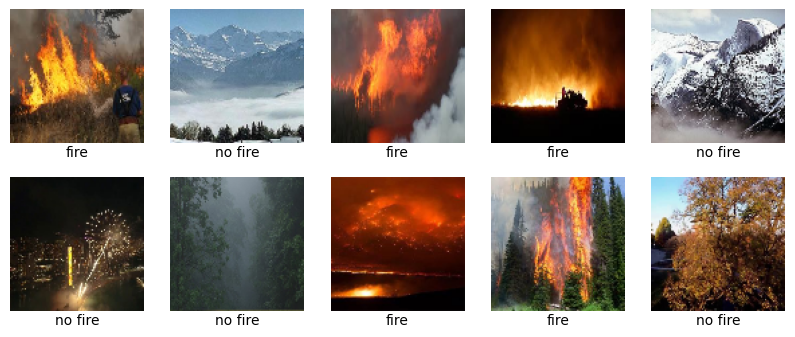

In [5]:
# Create a figure and axes
fig, ax = plt.subplots(2, 5, figsize=(10, 4))

# Plot the images on the axes
for i, image in enumerate(images):
    texto = "fire" if sample.iloc[i].label == 0 else "no fire"
    if i < 5:
        ax[0, i].imshow(image)
        ax[0, i].text(0.5, -0.1, texto, transform=ax[0, i].transAxes, ha="center")
        ax[0, i].axis('off')
    else:
        ax[1, i-5].imshow(image)
        ax[1, i-5].text(0.5, -0.1, texto, transform=ax[1, i-5].transAxes, ha="center")
        ax[1, i-5].axis('off')
# Show the figure
plt.show()


In [6]:
# Convert lists to numpy arrays
X_sample = np.array(X)
Y_sample = np.array(y)

X_test = np.array(X_test)
y_test = np.array(y_test)

# Normalize the pixel values to be between 0 and 1
X_sample = X_sample.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Split the dataset into training and validation sets
from sklearn.model_selection import train_test_split
X_train, X_val, Y_train, Y_val = train_test_split(X_sample, Y_sample, train_size=0.7, shuffle=True)


In [7]:
# Build the CNN model
model = models.Sequential([
    layers.Input(shape=(img_size, img_size, 3)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
      layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])



In [8]:
# Define callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=30, restore_best_weights=True)
reduce_lr_on_plateau = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5)
checkpoint = callbacks.ModelCheckpoint("best_forest_fire_model.keras", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

# Define and fit data generator
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the data
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # dimesion reduction
        rotation_range=10,  # randomly rotate images in the range 10 degrees
        zoom_range=0.1, # Randomly zoom image 10%
        width_shift_range=0.1,  # randomly shift images horizontally 10%
        height_shift_range=0.1,  # randomly shift images vertically 10%
        horizontal_flip=True,  # randomly flip images
        vertical_flip=False)  # randomly flip images

datagen.fit(X_train)

In [9]:
# Train the model
history = model.fit(datagen.flow(X_train, Y_train, batch_size=48), 
                    batch_size=48,
                    epochs=10,
                    validation_data=(X_val, Y_val),
                    callbacks=[early_stopping, reduce_lr_on_plateau, checkpoint])

# Evaluate the model
test_loss, test_acc = model.evaluate(X_val, Y_val)
print('Test accuracy:', test_acc)


Epoch 1/10


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7740 - loss: 0.4669
Epoch 1: val_accuracy improved from -inf to 0.91795, saving model to best_forest_fire_model.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.7753 - loss: 0.4652 - val_accuracy: 0.9179 - val_loss: 0.2188 - learning_rate: 0.0010
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9047 - loss: 0.2638
Epoch 2: val_accuracy improved from 0.91795 to 0.93187, saving model to best_forest_fire_model.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9048 - loss: 0.2635 - val_accuracy: 0.9319 - val_loss: 0.1825 - learning_rate: 0.0010
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9228 - loss: 0.2170
Epoch 3: val_accuracy improved from 0.93187 to 0.93407, saving model to best_forest_fire_model.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9229 - loss: 0.2166 - val_accuracy: 0.9341 - val_loss: 0.1778 - learning_rate: 0.0010
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/s

In [10]:
# Save the model
model.save('best_forest_fire_model.keras') ######



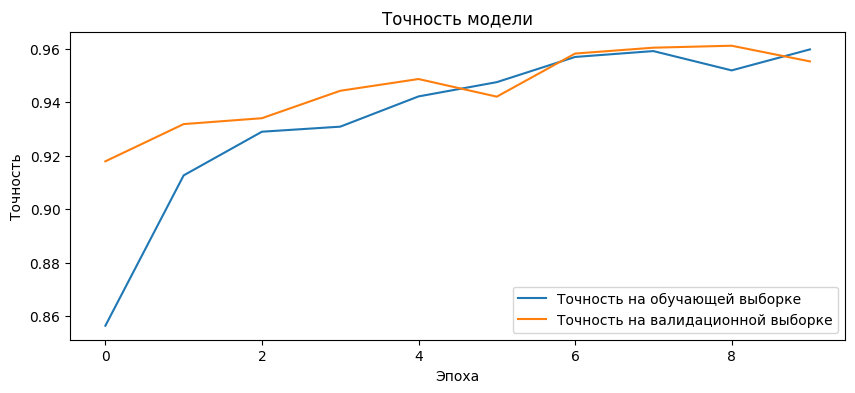

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Точность на обучающей выборке')
plt.plot(history.history['val_accuracy'], label='Точность на валидационной выборке')
plt.title('Точность модели')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()
plt.show()

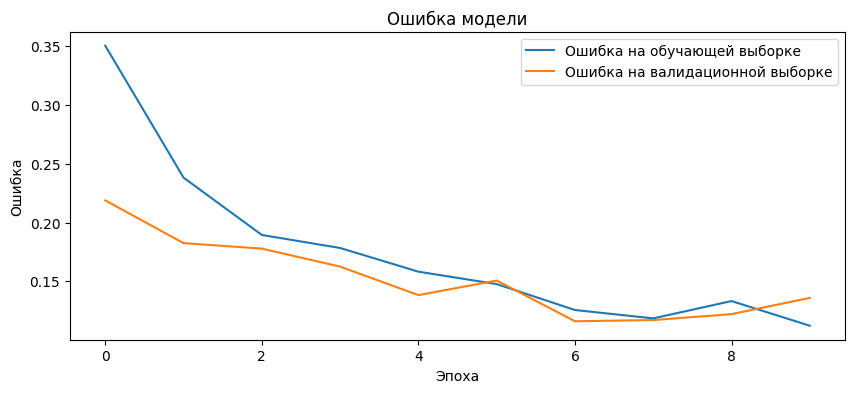

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Ошибка на обучающей выборке')
plt.plot(history.history['val_loss'], label='Ошибка на валидационной выборке')
plt.title('Ошибка модели')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка')
plt.legend()
plt.show()

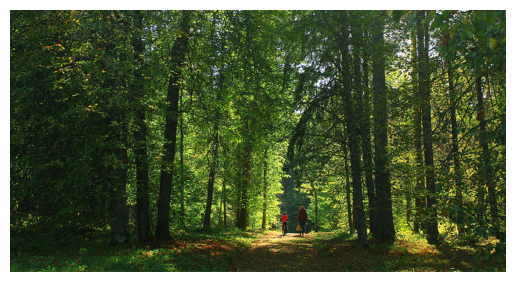

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Predicted class: Non-Fire


In [13]:
# Save the model
#model.save('best_forest_fire_model.keras')

# Load the model
loaded_model = models.load_model('/kaggle/working/best_forest_fire_model.keras')

# Example of predicting using the loaded model
image_path = "/kaggle/input/forest-fire-images/Data/Test_Data/Non_Fire/NF_15.jpg"  # Replace with the path to your image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Display the image
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()
img = cv2.resize(img, (img_size, img_size))
img = img.astype('float32') / 255.0  # Normalize pixel values
img = np.expand_dims(img, axis=0)  # Add batch dimension

prediction = loaded_model.predict(img)
predicted_class = "Fire" if prediction[0][0] < 0.4 else "Non-Fire"
print("Predicted class:", predicted_class)


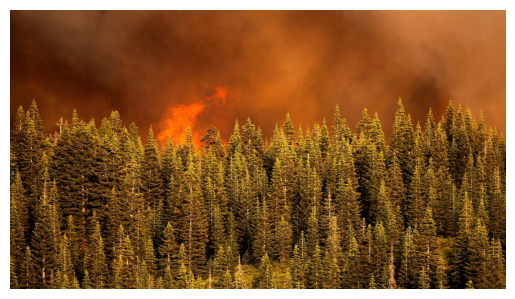

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Predicted class: Fire


In [14]:
image_path = "/kaggle/input/forest-fire-images/Data/Test_Data/Fire/F_14.jpg"  # Replace with the path to your image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Display the image
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()
img = cv2.resize(img, (img_size, img_size))
img = img.astype('float32') / 255.0  # Normalize pixel values
img = np.expand_dims(img, axis=0)  # Add batch dimension

prediction = loaded_model.predict(img)
predicted_class = "Fire" if prediction[0][0] < 0.4 else "Non-Fire"
print("Predicted class:", predicted_class)

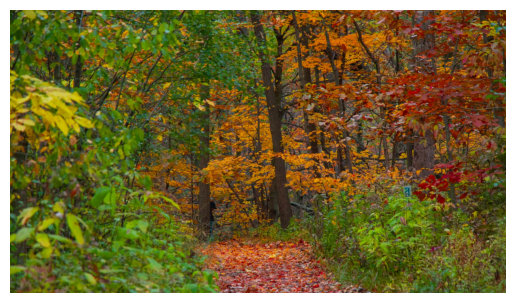

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Predicted class: Non-Fire


In [15]:
image_path = "/kaggle/input/forest-fire-images/Data/Test_Data/Non_Fire/NF_19.jpg"  # Replace with the path to your image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Display the image
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()
img = cv2.resize(img, (img_size, img_size))
img = img.astype('float32') / 255.0  # Normalize pixel values
img = np.expand_dims(img, axis=0)  # Add batch dimension

prediction = loaded_model.predict(img)
predicted_class = "Fire" if prediction[0][0] < 0.4 else "Non-Fire"
print("Predicted class:", predicted_class)

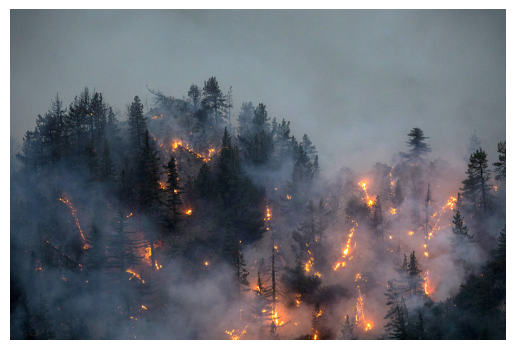

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted class: Fire


In [16]:
image_path = "/kaggle/input/forest-fire-images/Data/Test_Data/Fire/F_18.jpg"  # Replace with the path to your image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Display the image
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()
img = cv2.resize(img, (img_size, img_size))
img = img.astype('float32') / 255.0  # Normalize pixel values
img = np.expand_dims(img, axis=0)  # Add batch dimension

prediction = loaded_model.predict(img)
predicted_class = "Fire" if prediction[0][0] < 0.4 else "Non-Fire"
print("Predicted class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Prediction probability: 0.0159
Contour area: 3752.00
Contour area: 19469.00
Contour area: 2889.50
Contour area: 342.00
Contour area: 4183.50
Contour area: 472.50


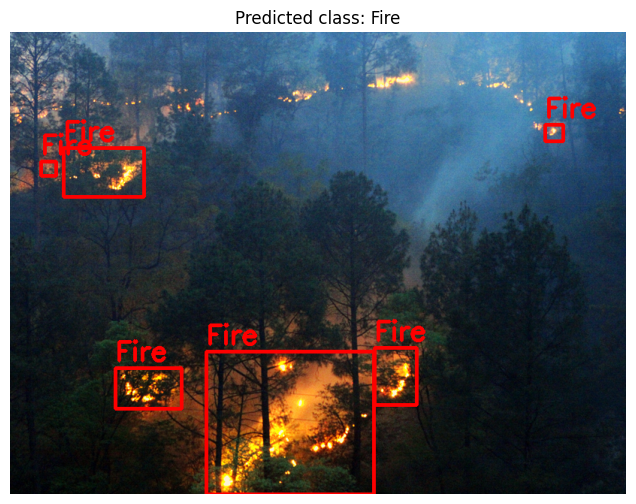

Predicted class: Fire


In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import models

# Load the model
loaded_model = models.load_model('/kaggle/working/best_forest_fire_model.keras')

# Function to detect and highlight fire regions
def detect_and_highlight_fire(image_path, img_size=100, threshold=0.5):
    # Read and preprocess the image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Failed to load image at {image_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize for model input
    img_resized = cv2.resize(img_rgb, (img_size, img_size))
    img_normalized = img_resized.astype('float32') / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)  # Shape: (1, 100, 100, 3)
    
    # Predict using the model
    prediction = loaded_model.predict(img_input)
    predicted_class = "Fire" if prediction[0][0] < threshold else "Non-Fire"
    print(f"Prediction probability: {prediction[0][0]:.4f}")
    
    # Initialize image to display
    img_display = img_rgb.copy()
    
    # Process fire detection only if classified as "Fire"
    if predicted_class == "Fire":
        # Create a mask for fire regions
        hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
        
        # Range for red/orange fire (hue 0-15)
        lower_red = np.array([0, 150, 150])
        upper_red = np.array([15, 255, 255])
        red_mask = cv2.inRange(hsv, lower_red, upper_red)
        
        # Range for orange fire (hue 15-25, stricter to avoid yellow)
        lower_orange = np.array([15, 150, 150])
        upper_orange = np.array([25, 255, 255])
        orange_mask = cv2.inRange(hsv, lower_orange, upper_orange)
        
        # Combine the masks
        fire_mask = cv2.bitwise_or(red_mask, orange_mask)
        
        # Add brightness and saturation filters to exclude dim or grayish areas
        brightness_mask = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY) > 150
        saturation_mask = hsv[:, :, 1] > 120
        fire_mask = cv2.bitwise_and(fire_mask, fire_mask, mask=(brightness_mask & saturation_mask).astype(np.uint8))
        
        # Add texture filter to exclude smooth surfaces (like sand)
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        sobel = np.sqrt(sobelx**2 + sobely**2)
        texture_mask = (sobel > 50).astype(np.uint8) * 255
        fire_mask = cv2.bitwise_and(fire_mask, fire_mask, mask=texture_mask)
        
        # Apply morphological operations: dilate to merge nearby regions, close to fill gaps, open to reduce noise
        kernel = np.ones((7, 7), np.uint8)
        fire_mask = cv2.morphologyEx(fire_mask, cv2.MORPH_DILATE, kernel, iterations=3)  # Moderate increase to merge small areas
        fire_mask = cv2.morphologyEx(fire_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
        fire_mask = cv2.morphologyEx(fire_mask, cv2.MORPH_OPEN, kernel, iterations=2)
        
        # Exclude upper part of the image (likely sky or smoke)
        height, width = fire_mask.shape
        sky_threshold = int(height * 0.2)  # Ignore top 20% of the image
        fire_mask[:sky_threshold, :] = 0
        
        # Find contours of fire regions to add labels
        contours, _ = cv2.findContours(fire_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            area = cv2.contourArea(contour)
            if area > 150:  # Slightly higher threshold to balance small bright spots and noise
                print(f"Contour area: {area:.2f}")
                # Get bounding box for contour
                x, y, w, h = cv2.boundingRect(contour)
                # Add "Fire" label
                cv2.putText(img_display, "Fire", (x, y - 10), 
                           cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 0, 0), 3)
                # Draw rectangle around fire region
                cv2.rectangle(img_display, (x, y), (x + w, y + h), (255, 0, 0), 3)
    
    # Display the result
    plt.figure(figsize=(10, 6))
    plt.imshow(img_display)
    plt.title(f"Predicted class: {predicted_class}")
    plt.axis('off')
    plt.show()
    
    return predicted_class

# Example usage
image_path = "/kaggle/input/forest-fire-images/Data/Test_Data/Fire/F_24.jpg"  # Replace with your image path
try:
    predicted_class = detect_and_highlight_fire(image_path)
    print("Predicted class:", predicted_class)
except Exception as e:
    print(f"Error: {e}")

Вероятность предсказания: 0.9995


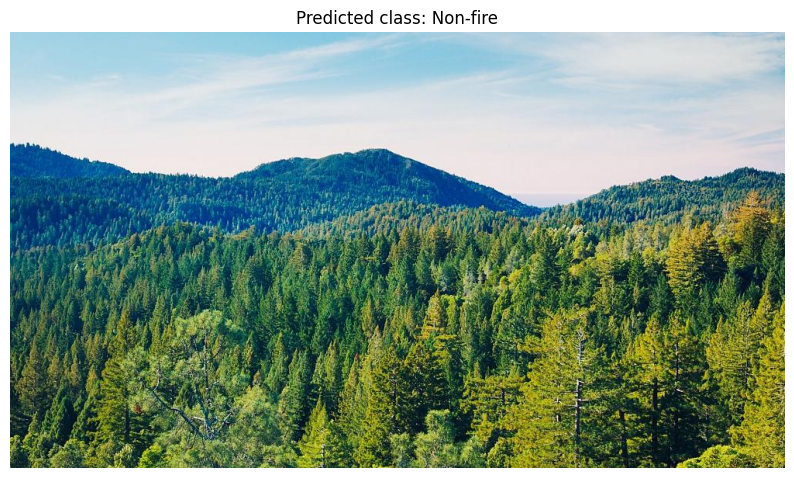

Predicted class: Non-fire


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import models

# Load the model
try:
    loaded_model = models.load_model('/kaggle/working/best_forest_fire_model.keras')
except Exception as e:
    raise ValueError(f"Failed to load model: {e}")

# Function to detect and highlight fire regions
def detect_and_highlight_fire(image_path, img_size=100, threshold=0.5):
    # Read and preprocess the image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Failed to load image at {image_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize for model input
    img_resized = cv2.resize(img_rgb, (img_size, img_size), interpolation=cv2.INTER_AREA)
    img_normalized = img_resized.astype('float32') / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)  # Shape: (1, 100, 100, 3)
    
    # Predict using the model
    prediction = loaded_model.predict(img_input, verbose=0)
    predicted_class = "Fire" if prediction[0][0] < threshold else "Non-fire"
    print(f"Вероятность предсказания: {prediction[0][0]:.4f}")
    
    # Initialize image to display
    img_display = img_rgb.copy()
    
    # Process fire detection only if classified as "Fire"
    if predicted_class == "Fire":
        # Create a mask for fire regions
        hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
        
        # Range for red fire (hue 0-15)
        lower_red = np.array([0, 150, 150])
        upper_red = np.array([15, 255, 255])
        red_mask = cv2.inRange(hsv, lower_red, upper_red)
        
        # Range for orange fire (hue 15-25, stricter to avoid yellow)
        lower_orange = np.array([15, 180, 150])  # Increased saturation to avoid sandy tones
        upper_orange = np.array([25, 255, 255])
        orange_mask = cv2.inRange(hsv, lower_orange, upper_orange)
        
        # Exclude yellow tones (possible sand) hue 25-40
        lower_yellow = np.array([25, 100, 150])
        upper_yellow = np.array([40, 255, 255])
        yellow_mask = cv2.inRange(hsv, lower_yellow, upper_yellow)
        
        # Combine masks and exclude yellow
        fire_mask = cv2.bitwise_or(red_mask, orange_mask)
        fire_mask = cv2.bitwise_and(fire_mask, cv2.bitwise_not(yellow_mask))
        
        # Add brightness and saturation filters to exclude dim or grayish areas
        brightness_mask = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY) > 180  # Increased to 180
        saturation_mask = hsv[:, :, 1] > 150  # Increased to 150
        fire_mask = cv2.bitwise_and(fire_mask, fire_mask, mask=(brightness_mask & saturation_mask).astype(np.uint8))
        
        # Add texture filter with enhanced threshold
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        sobel = np.sqrt(sobelx**2 + sobely**2)
        texture_mask = (sobel > 70).astype(np.uint8) * 255  # Increased to 70
        fire_mask = cv2.bitwise_and(fire_mask, fire_mask, mask=texture_mask)
        
        # Apply morphological operations
        kernel = np.ones((7, 7), np.uint8)
        fire_mask = cv2.morphologyEx(fire_mask, cv2.MORPH_DILATE, kernel, iterations=3)
        fire_mask = cv2.morphologyEx(fire_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
        fire_mask = cv2.morphologyEx(fire_mask, cv2.MORPH_OPEN, kernel, iterations=2)
        
        # Exclude upper part (likely sky or smoke)
        height, width = fire_mask.shape
        sky_threshold = int(height * 0.2)
        fire_mask[:sky_threshold, :] = 0
        
        # Find contours of fire regions to add labels
        contours, _ = cv2.findContours(fire_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            area = cv2.contourArea(contour)
            if area > 200:  # Increased to 200 to filter small sandy areas
                print(f"Площадь контура: {area:.2f}")
                x, y, w, h = cv2.boundingRect(contour)
                cv2.putText(img_display, "Fire", (x, y - 10), 
                           cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 0, 0), 3)
                cv2.rectangle(img_display, (x, y), (x + w, y + h), (255, 0, 0), 3)
    
    # Display the result
    plt.figure(figsize=(10, 6))
    plt.imshow(img_display)
    plt.title(f"Predicted class: {predicted_class}")
    plt.axis('off')
    plt.show()
    
    return predicted_class

# Example usage
image_path = "/kaggle/input/forest-fire-images/Data/Test_Data/Non_Fire/NF_23.jpg"
try:
    predicted_class = detect_and_highlight_fire(image_path)
    print("Predicted class:", predicted_class)
except Exception as e:
    print(f"Ошибка: {e}")